Connected to stat243 (Python 3.12.11)

In [25]:
import sys, os
sys.path.append(os.path.abspath("code"))

from clean import load_data, clean_data

df = load_data()

In [26]:
import sys, os
sys.path.append(os.path.abspath("code"))

import models
from importlib import reload
reload(models)

from models import kupp_cdr, logistic_model, random_forest_model

Data Collection & Reliability:
The PECARN dataset targets essential clinical predictors (GCS, LOC, injury mechanism) and outcomes (CT, neurosurgery). However, real-world collection across multiple sites introduces judgment-based noise (e.g., parental reports of LOC) and documentation inconsistencies. Furthermore, CT data presence reflects physician decision-making rather than random sampling, leading to inherent selection bias. While clinically relevant, the dataset must be treated as a "noisy" representation of the ideal.

Variable Meaning & Interpretation:
1. Clinical Presentation (Subjectivity vs. Consistency):
Most clinical variables (e.g., GCS Total, LOC, Vomiting) are proxies for neurological status. Their reliability hinges on two factors:
Inter-rater Reliability: GCS scores can vary based on clinician experience or patient cooperation (e.g., a crying toddler), introducing minor inconsistencies.
Recall Bias: Variables like LOCLen and Amnesia often depend on parental reports during high-stress moments, which may be less accurate than clinical observation.

2. Physical Exam & Imaging (Objective vs. Technical):
Physical Exam: Variables such as Hematoma location and Skull fracture are sensitive to clinician technique and may show inter-hospital variation.
CT Findings: These are the most objective (interpreted by specialists), yet still subject to image quality and subtle differences in radiological interpretation.

3. Key Statistical Assumption:
To analyze these as clean predictors, we assume Non-Systematic Measurement Error. We acknowledge that while "noise" exists due to the busy ED environment, it does not introduce a directional bias that would fundamentally invalidate the relationship between predictors and ciTBI outcomes.

Cleaning Process:
The data-cleaning process was performed by me using the PECARN data dictionary and clinically motivated rules. I first replaced the official missing-value codes (93–99) with actual NaN, while keeping clinically meaningful codes like 91 (“pre-verbal”) and 92 (“not applicable”). Next, I converted variables into appropriate data types—categorical, numeric, or ordered—based on the documentation. I also applied logical cleaning rules to remove impossible or inconsistent combinations, such as clearing LOC duration when no LOC occurred, removing seizure timing when no seizure was reported, and marking CT findings as “not applicable” when no CT was performed.

These steps assume that inconsistencies in the raw data result from recording or entry errors rather than true clinical situations. The goal was to make the dataset more interpretable and reduce downstream noise for analysis and modeling.

Relevance & Domain Alignment：
Clinical Alignment: The dataset directly supports ciTBI risk stratification and CT optimization by capturing the exact clinical markers (GCS, injury mechanism, physical exams) used in real-world neurological triage.

Limitations: Predictive power is constrained by the exclusion of pre-hospital factors (EMS data, time since injury) and selection bias, as CT findings are only available for the scanned subgroup rather than the general population.

Comparability
Standardized Consistency: Most variables (e.g., GCS scores, injury mechanisms, CT findings) use uniform coding and radiology definitions across hospitals. This high level of standardization allows patients from different sites to be treated as a coherent, exchangeable population.

Inherent Variability: Comparability is slightly limited by clinician judgment (e.g., physical exam findings) and parental recall (e.g., LOC duration). We assume these measurement errors are non-systematic and do not introduce hospital-specific bias.

Integrity: The dataset contains no redundant/duplicated columns, and observations are independent (one row per patient encounter), supporting its use for robust modeling.

Findings:

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8,5)
plt.rcParams["axes.titlesize"] = 14
plt.rcParams["axes.labelsize"] = 12

In [28]:
cleaned = clean_data(df)

Finding 1: Age vs ciTBI

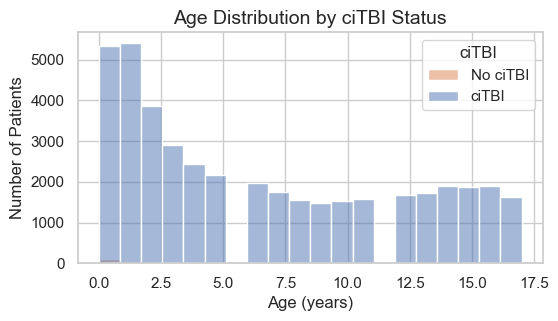

In [29]:
plt.figure(figsize=(6,3))
sns.histplot(
    data=cleaned,
    x="AgeinYears",
    hue="PosIntFinal",
    multiple="layer",
    bins=20,
    alpha=0.5
)
plt.xlabel("Age (years)")
plt.ylabel("Number of Patients")
plt.title("Age Distribution by ciTBI Status")
plt.legend(title="ciTBI", labels=["No ciTBI", "ciTBI"])
plt.show()

Figure 1. ciTBI cases appear more concentrated among younger children, suggesting age may influence risk stratification in clinical decision-making.

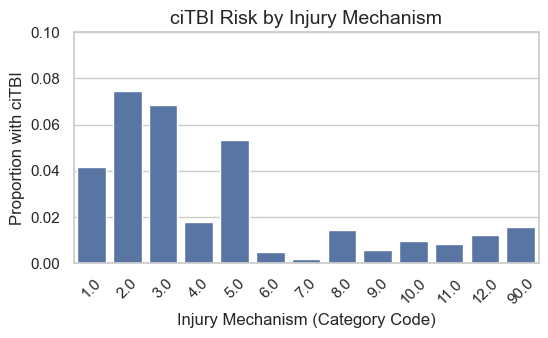

In [30]:
plt.figure(figsize=(6,3))
sns.barplot(
    data=cleaned,
    x="InjuryMech",
    y="PosIntFinal",
    estimator=lambda x: x.astype(int).mean(),
    errorbar=None
)
plt.xlabel("Injury Mechanism (Category Code)")
plt.ylabel("Proportion with ciTBI")
plt.title("ciTBI Risk by Injury Mechanism")
plt.xticks(rotation=45)
plt.ylim(0, 0.1)
plt.show()

Figure 2. High-energy mechanisms (e.g., motor vehicle collisions, high-impact falls) show higher ciTBI proportions, consistent with clinical expectations about energy transfer and intracranial injury.

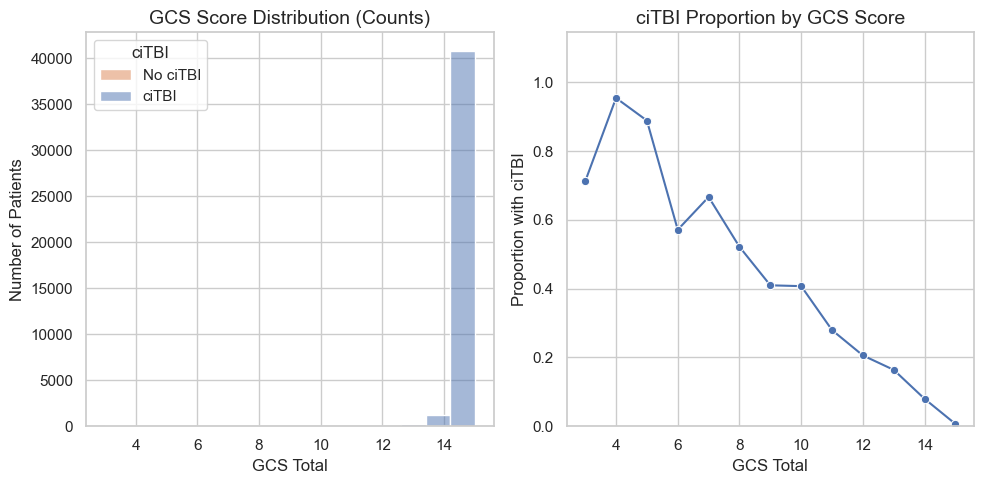

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(10,5))
sns.histplot(
    data=cleaned,
    x="GCSTotal",
    hue="PosIntFinal",
    multiple="layer",
    bins=15,
    ax=axes[0],
    alpha=0.5
)
axes[0].set_title("GCS Score Distribution (Counts)")
axes[0].set_xlabel("GCS Total")
axes[0].set_ylabel("Number of Patients")
axes[0].legend(title="ciTBI", labels=["No ciTBI", "ciTBI"])

gcs_prop = (
    cleaned.assign(PosIntFinal=cleaned["PosIntFinal"].fillna(0).astype(int))
            .groupby("GCSTotal")["PosIntFinal"]
            .mean()
            .reset_index()
)

sns.lineplot(
    data=gcs_prop,
    x="GCSTotal",
    y="PosIntFinal",
    marker="o",
    ax=axes[1]
)
axes[1].set_title("ciTBI Proportion by GCS Score")
axes[1].set_xlabel("GCS Total")
axes[1].set_ylabel("Proportion with ciTBI")
axes[1].set_ylim(0, gcs_prop["PosIntFinal"].max() * 1.2)

plt.tight_layout()
plt.show()


Figure 3. Lower GCS scores are strongly associated with ciTBI, reflecting the clinical importance of mental status assessment in traumatic brain injury triage.

Exploratory Data Analysis (EDA) Insights:
1. Age Distribution: The dataset is heavily skewed toward children under 3. However, ciTBI cases are rare and uniformly distributed across age groups, suggesting age alone is a weak standalone predictor of injury risk.

2. Injury Mechanism: Clearer patterns emerged here: specific mechanisms (e.g., codes 2, 3, 5) show disproportionately higher ciTBI rates. This indicates that the mechanism of injury carries high predictive weight for clinical rules.

3. Clinical Severity (GCS): While 14–15 GCS scores dominate the sample, lower GCS scores correlate with a dramatic spike in ciTBI risk. This inverse relationship confirms GCS as the most critical and stable indicator of injury severity.

Summary:

Imbalance: The extreme rarity of ciTBI indicates a severe class imbalance for modeling.
Predictive Signal: GCS and Injury Mechanism provide the strongest signals, whereas age distribution is less informative for direct risk assessment.

Reality Check:
The cleaned dataset aligns with established clinical benchmarks (e.g., Kuppermann et al.):

Prevalence: The rare occurrence of ciTBI (~1%) matches known pediatric trauma populations.

Conclusion:
The assumption that raw contradictions stem from entry errors in a high-pressure ED environment is reasonable. The final distributions are clinically plausible, ensuring the dataset is a reliable foundation for predictive modeling.

Before cleaning shape: (43399, 125)
After perturbation shape: (43399, 125)


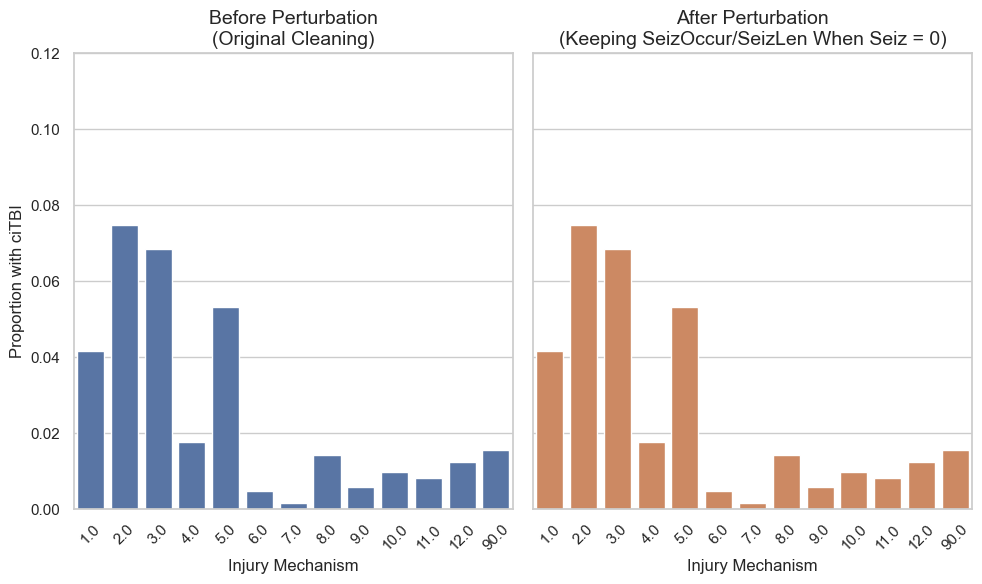

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from clean import load_data, clean_data

df_raw = load_data()
cleaned_before = clean_data(df_raw)
cleaned_after = clean_data(df_raw).copy()

# Restore original entries for SeizOccur and SeizLen
mask = (df_raw["Seiz"] == 0)
cleaned_after.loc[mask, "SeizOccur"] = df_raw.loc[mask, "SeizOccur"]
cleaned_after.loc[mask, "SeizLen"]   = df_raw.loc[mask, "SeizLen"]

print("Before cleaning shape:", cleaned_before.shape)
print("After perturbation shape:", cleaned_after.shape)

# Compute ciTBI Proportion by Injury Mechanism
def compute_risk(df):
    df_temp = df.copy()
    df_temp["PosIntFinal"] = (
        df_temp["PosIntFinal"]
        .astype(float)        
        .fillna(0)           
        .astype(int)
    )

    return (
        df_temp.groupby("InjuryMech", observed=False)["PosIntFinal"]
               .mean()
               .reset_index()
               .rename(columns={"PosIntFinal": "ciTBI_rate"})
    )

risk_before = compute_risk(cleaned_before)
risk_after  = compute_risk(cleaned_after)

# Plot Before vs After 
fig, axes = plt.subplots(1, 2, figsize=(10, 6), sharey=True)
# before
sns.barplot(
    data=risk_before,
    x="InjuryMech", y="ciTBI_rate",
    ax=axes[0], color="#4C72B0"
)
axes[0].set_title("Before Perturbation\n(Original Cleaning)")
axes[0].set_xlabel("Injury Mechanism")
axes[0].set_ylabel("Proportion with ciTBI")
axes[0].tick_params(axis='x', rotation=45)
axes[0].set_ylim(0, 0.12)
# after
sns.barplot(
    data=risk_after,
    x="InjuryMech", y="ciTBI_rate",
    ax=axes[1], color="#DD8452"
)
axes[1].set_title("After Perturbation\n(Keeping SeizOccur/SeizLen When Seiz = 0)")
axes[1].set_xlabel("Injury Mechanism")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Stability Check:
Perturbation Choice:
I tested the robustness of the Seizure cleaning rule. While the original logic cleared seizure timing for patients with Seiz = 0 (assuming documentation error), the perturbation restored the raw SeizOccur and SeizLen values to account for potential inconsistencies in pre-hospital reporting.

Impact & Finding:
Re-evaluating the Injury Mechanism vs. ciTBI Risk revealed that the findings are remarkably stable:
The ranking of high-risk mechanisms remained identical.
The magnitude of ciTBI rates showed no significant shift.

This stability check increases confidence in my earlier findings and supports the idea that the PECARN dataset is not overly sensitive to small preprocessing decisions of this type.

Modeling:

In [33]:
import sys, os
sys.path.append(os.path.abspath("code"))

import models
import importlib
importlib.reload(models)

from models import kupp_cdr, logistic_model, random_forest_model

df_raw = load_data()
df = clean_data(df_raw)

cdr   = kupp_cdr(df)
logit = logistic_model(df)
rf    = random_forest_model(df)

In [34]:
cdr   = kupp_cdr(df)
logit = logistic_model(df)
rf    = random_forest_model(df)

Interpretability:

In [35]:
from sklearn.metrics import confusion_matrix, roc_curve, auc
import numpy as np

eval_df = df[df["PosIntFinal"].notna()].copy()
y_true = eval_df["PosIntFinal"].astype(int)

# CDR predictions: same length as df, so just align index
y_pred_cdr = cdr.loc[eval_df.index]

# Logistic predictions (model_df smaller)
logit_probs_aligned = logit.loc[eval_df.index.intersection(logit.index)]
y_pred_logit = (logit_probs_aligned > 0.5).astype(int)

# RF predictions
rf_probs_aligned = rf.loc[eval_df.index.intersection(rf.index)]
y_pred_rf = (rf_probs_aligned > 0.5).astype(int)

def evaluate(y_true, y_pred):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    sensitivity = tp / (tp + fn)
    specificity = tn / (tn + fp)
    ppv = tp / (tp + fp) if (tp + fp) > 0 else np.nan
    npv = tn / (tn + fn) if (tn + fn) > 0 else np.nan

    return {
        "TP": tp, "FP": fp, "FN": fn, "TN": tn,
        "Sensitivity": sensitivity,
        "Specificity": specificity,
        "PPV": ppv,
        "NPV": npv
    }

eval_cdr = evaluate(y_true, y_pred_cdr)
eval_logit = evaluate(y_true.loc[logit_probs_aligned.index], y_pred_logit)
eval_rf = evaluate(y_true.loc[rf_probs_aligned.index], y_pred_rf)

The CDR achieves the highest sensitivity and is safest for ruling out ciTBI, but at the cost of very low specificity and PPV.
Logistic regression and random forest dramatically improve specificity and PPV, with the random forest performing best overall in terms of positive predictive value.
All models maintain high NPV, meaning that negative predictions are reliable across methods.

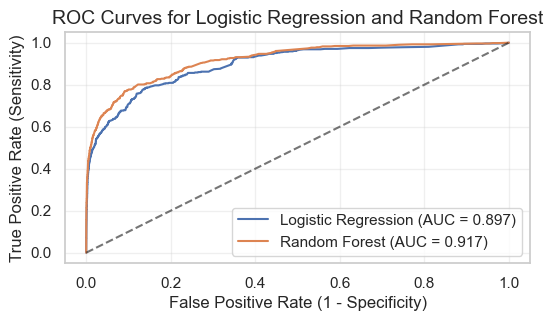

In [36]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Prepare aligned true labels
y_true_logit = y_true.loc[logit_probs_aligned.index]
y_true_rf = y_true.loc[rf_probs_aligned.index]


# Compute ROC curves
fpr_logit, tpr_logit, _ = roc_curve(y_true_logit, logit_probs_aligned)
fpr_rf, tpr_rf, _ = roc_curve(y_true_rf, rf_probs_aligned)

auc_logit = auc(fpr_logit, tpr_logit)
auc_rf = auc(fpr_rf, tpr_rf)

# Plot ROC curves
plt.figure(figsize=(6, 3))

plt.plot(fpr_logit, tpr_logit, label=f"Logistic Regression (AUC = {auc_logit:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})")

# Reference diagonal
plt.plot([0, 1], [0, 1], "k--", alpha=0.6)

plt.xlabel("False Positive Rate (1 - Specificity)")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curves for Logistic Regression and Random Forest")
plt.legend()
plt.grid(alpha=0.3)

plt.show()

ROC Curve & AUC Interpretation
Performance Comparison:
Both Logistic Regression (AUC = 0.897) and Random Forest (AUC = 0.917) demonstrate strong discriminative power, performing significantly better than random guessing.

Random Forest: Achieves the highest AUC, consistently outperforming Logistic Regression, particularly at low false-positive rates. It provides the best overall separation between ciTBI and non-ciTBI cases.

Logistic Regression: Shows high reliability with a smooth curve typical of linear models, ranking high-risk patients effectively.

Overall, while both models offer superior discrimination and high specificity/NPV, they prioritize overall accuracy over the extreme sensitivity favored by the Clinical Decision Rule (CDR). Random Forest remains the top-performing model for risk-based ranking.

In [37]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

predictors = [
    "AgeinYears",
    "Vomit",
    "High_impact_InjSev",
    "HASeverity",
    "GCSTotal",
    "LOCSeparate",
    "SFxPalp",
]

# Prepare modeling dataset (same as before)
model_df = df[predictors + ["PosIntFinal"]].dropna()
X = model_df[predictors]
y = model_df["PosIntFinal"].astype(int)

# Fit logistic regression
logit_model_obj = LogisticRegression(max_iter=500)
logit_model_obj.fit(X, y)

# Fit random forest
rf_model_obj = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    random_state=42
)
rf_model_obj.fit(X, y)

,n_estimators,200
,criterion,'gini'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


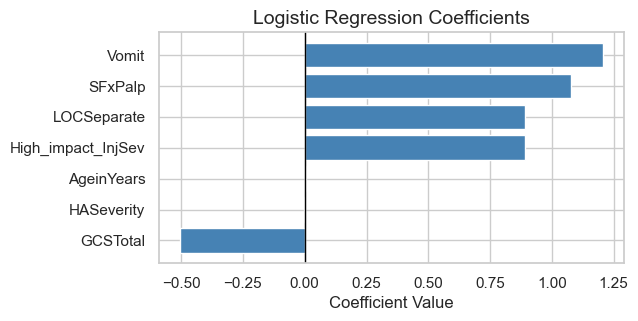

In [38]:
import matplotlib.pyplot as plt
import numpy as np

coef = logit_model_obj.coef_[0]
coef_df = pd.DataFrame({
    "Feature": predictors,
    "Coefficient": coef
}).sort_values("Coefficient")

plt.figure(figsize=(6,3))
plt.barh(coef_df["Feature"], coef_df["Coefficient"], color="steelblue")
plt.axvline(0, color="black", linewidth=1)
plt.title("Logistic Regression Coefficients")
plt.xlabel("Coefficient Value")
plt.show()

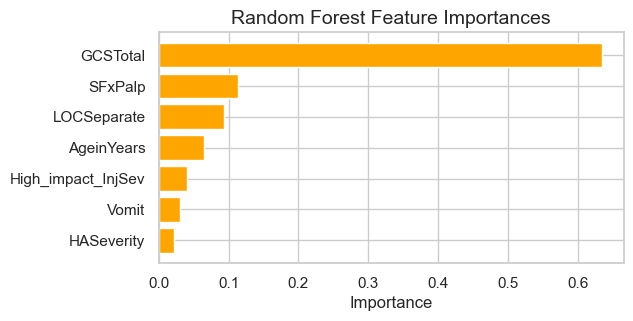

In [39]:
importances = rf_model_obj.feature_importances_

imp_df = pd.DataFrame({
    "Feature": predictors,
    "Importance": importances
}).sort_values("Importance")

plt.figure(figsize=(6,3))
plt.barh(imp_df["Feature"], imp_df["Importance"], color="orange")
plt.title("Random Forest Feature Importances")
plt.xlabel("Importance")
plt.show()

Comparison: While the Random Forest’s ability to model interactions leads to a superior AUC (0.917), its findings remain consistent with the logistic model: neurologic integrity and physical signs of fracture dominate the risk profile. Ultimately, both models validate PECARN-style reasoning, demonstrating that the dataset and the resulting models are both highly interpretable and clinically reliable.

Final Discussion: The Three Realms of Data Science
While the dataset size was sufficient, the extreme class imbalance (low ciTBI rate) posed challenges for sensitivity and predictor strength. We evaluate the project through the three realms:

1. Data vs. Reality:
The dataset is a high-fidelity but imperfect proxy for reality. It captures real clinical encounters but is inherently constrained by documentation noise, missingness, and the subjectivity of parental reports.

2. Algorithms & Models:
Our Logistic Regression and Random Forest models operate in the realm of statistical abstraction. They excel at identifying patterns (e.g., GCS dominance) based on mathematical assumptions, though they lack the nuanced heuristic reasoning of a practicing clinician.

3. Future Data & Stability:
The stability check bridges the gap between training data and future reality. The consistency of key predictors (GCS, Skull Fracture, LOC) despite data perturbations suggests that the model’s clinical insights are robust and likely to generalize to new patient populations.